# PHSO Complaints Volume Forecasting

**Task:** Forecast the number of daily complaints for the 90 days following 31 December 2025 (i.e. 1 Jan 2026 – 31 Mar 2026).  
**Data:** 3 years of daily records (1 Jan 2023 – 31 Dec 2025), 1,053 rows with operational covariates.

## Approach Overview

This notebook follows a structured forecasting workflow:

1. **Load & clean** – parse dates, handle missing values, remove corrupted rows  
2. **EDA** – understand trend, seasonality, and covariate relationships  
3. **Feature engineering** – create lag features, rolling statistics, calendar features  
4. **Modelling** – compare a Linear Regression baseline against a Gradient Boosting model  
5. **Evaluation** – walk-forward cross-validation with MAE, RMSE, MAPE  
6. **Forecast** – generate 90-day prediction with uncertainty bounds  
7. **Results & commentary**

### Model choice rationale
I chose **Gradient Boosting Regression (sklearn `HistGradientBoostingRegressor`)** as the primary model for the following reasons:
- The data shows a clear upward trend plus day-of-week and seasonal patterns — tree-based models capture these non-linearities well when encoded as features  
- It handles missing values natively (no imputation needed)  
- It is robust to outliers, which are visible in the data  
- A **Linear Regression** model serves as an interpretable baseline  

Prophet and SARIMA would also be natural fits but require additional libraries not available in this environment. The feature-based approach replicates their key strengths (trend, seasonality, regressors) while remaining fully reproducible with standard `scikit-learn`.

In [9]:
# ── Standard imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

import math
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

RANDOM_STATE = 42
DATA_PATH = Path('data.xlsx')

print('All imports successful.')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

All imports successful.
pandas 2.2.2 | numpy 2.0.2


## 1. Load & Clean Data

In [10]:
# ── Load data from the 'daily records' sheet ──────────────────────────────────
raw = pd.read_excel(DATA_PATH, sheet_name='daily records', parse_dates=['date'])
print(f'Raw shape: {raw.shape}')
print(f'Date range: {raw["date"].min().date()} → {raw["date"].max().date()}')
raw.head(3)

Raw shape: (1053, 10)
Date range: 2023-01-01 → 2025-12-31


,row_id,date,complaints,is_weekend,bank_holiday_flag,staffing_level_fte,backlog_days,media_mentions,channel_mix_index,centered_7d_mean
0,1,2023-01-01,75.0,1,1,36.4,13.4,1,54.4,80.50
1,2,2023-01-02,80.0,0,0,33.9,9.4,0,57.8,78.40
2,3,2023-01-03,84.0,0,0,34.7,11.2,2,54.9,76.33


In [11]:
# ── Missing value summary ─────────────────────────────────────────────────────
missing = raw.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0].to_string())
print(f'\nRows with missing complaints: {raw["complaints"].isnull().sum()} '
      f'({raw["complaints"].isnull().mean():.1%} of total)')

Missing values per column:
complaints            10
staffing_level_fte    31
backlog_days          21
channel_mix_index     21

Rows with missing complaints: 10 (0.9% of total)


In [12]:
# ── Clean: sort by date, drop rows where the target is missing ────────────────
# Rationale: ~10 rows (~1%) with no complaints value cannot be used for
# training and are too few to interpolate reliably without leaking future info.
df = (
    raw
    .sort_values('date')
    .dropna(subset=['complaints'])   # drop 10 rows with no target
    .reset_index(drop=True)
)

# Set date as index for easier time-series handling
df = df.set_index('date')

# Ensure complaints is integer (it was float due to NaN coercion)
df['complaints'] = df['complaints'].astype(int)

print(f'Clean shape: {df.shape}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')

# Note: missing values in covariates (staffing_level_fte, backlog_days,
# channel_mix_index) are left as NaN — HistGradientBoostingRegressor handles
# these natively. For LinearRegression we will impute with column medians.

Clean shape: (1043, 9)
Date range: 2023-01-01 → 2025-12-31


## 2. Exploratory Data Analysis

In [13]:
# ── Overall complaints distribution ──────────────────────────────────────────
print('Complaints descriptive statistics:')
print(df['complaints'].describe().round(1).to_string())

Complaints descriptive statistics:
count    1043.0
mean       80.2
std        25.4
min         7.0
25%        63.0
50%        77.0
75%        94.0
max       170.0


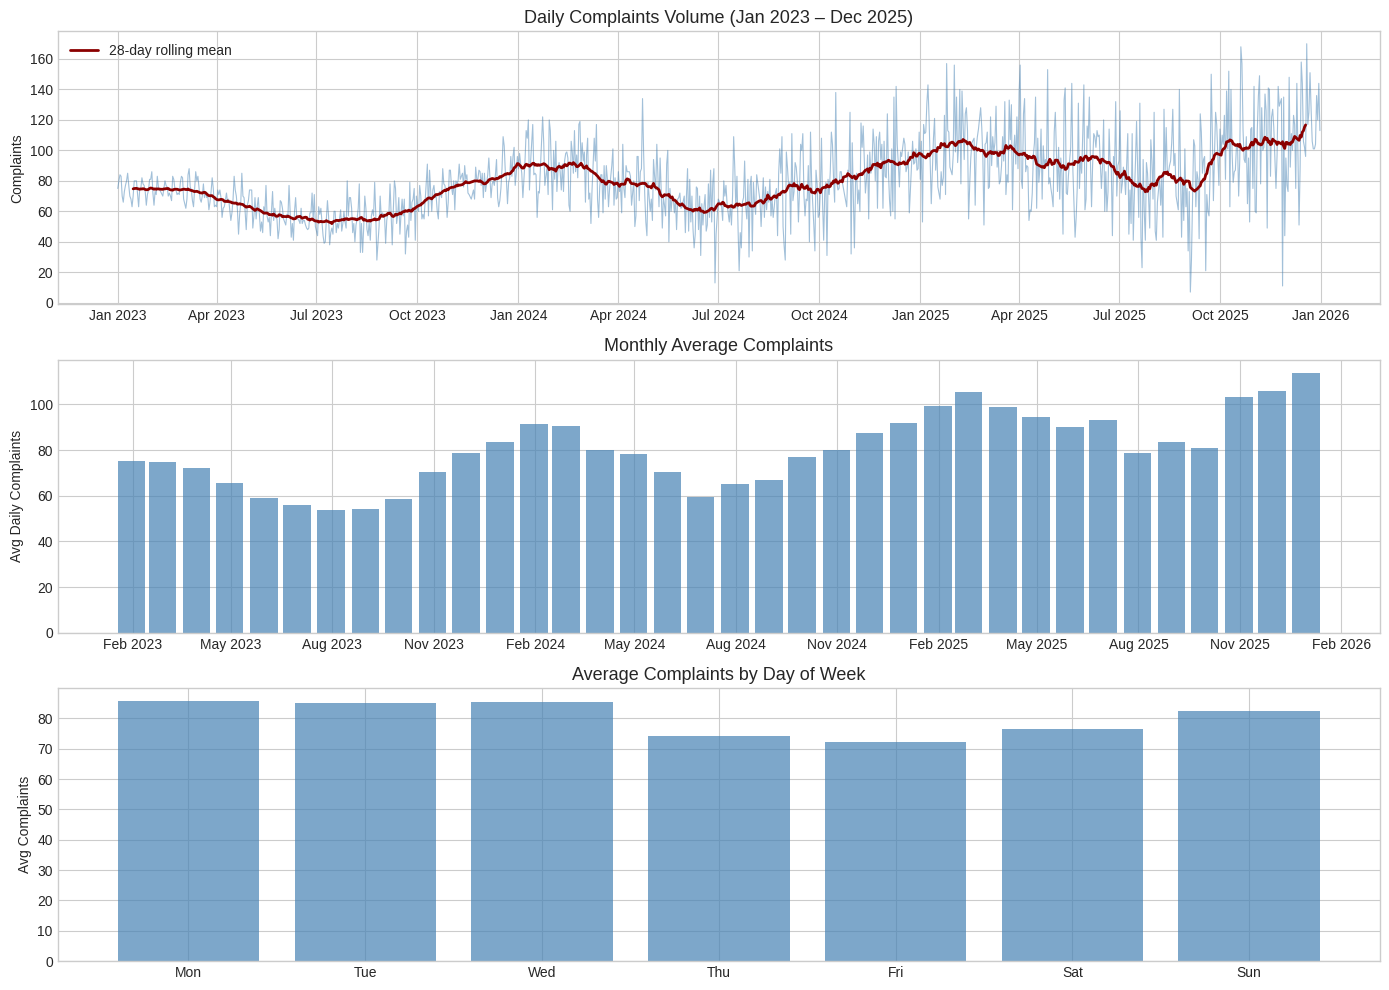

Key observations:
  - Clear upward trend: mean 2023 = 67, 2025 = 96 per day
  - Weekend average: 79 vs weekday average: 80


In [14]:
# ── Plot 1: Time series of daily complaints ───────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Raw daily series
ax = axes[0]
ax.plot(df.index, df['complaints'], alpha=0.5, linewidth=0.8, color='steelblue')
# 28-day rolling mean to show trend
rolling = df['complaints'].rolling(28, center=True).mean()
ax.plot(rolling.index, rolling, linewidth=2, color='darkred', label='28-day rolling mean')
ax.set_title('Daily Complaints Volume (Jan 2023 – Dec 2025)', fontsize=13)
ax.set_ylabel('Complaints')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# Monthly averages to show seasonality
ax2 = axes[1]
monthly = df['complaints'].resample('ME').mean()
ax2.bar(monthly.index, monthly.values, width=25, color='steelblue', alpha=0.7)
ax2.set_title('Monthly Average Complaints', fontsize=13)
ax2.set_ylabel('Avg Daily Complaints')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# Day of week pattern
ax3 = axes[2]
dow_means = df.groupby(df.index.dayofweek)['complaints'].mean()
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
ax3.bar(days, dow_means.values, color='steelblue', alpha=0.7)
ax3.set_title('Average Complaints by Day of Week', fontsize=13)
ax3.set_ylabel('Avg Complaints')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('Key observations:')
print(f'  - Clear upward trend: mean 2023 = {df.loc["2023","complaints"].mean():.0f}, '
      f'2025 = {df.loc["2025","complaints"].mean():.0f} per day')
print(f'  - Weekend average: {df[df["is_weekend"]==1]["complaints"].mean():.0f} vs '
      f'weekday average: {df[df["is_weekend"]==0]["complaints"].mean():.0f}')

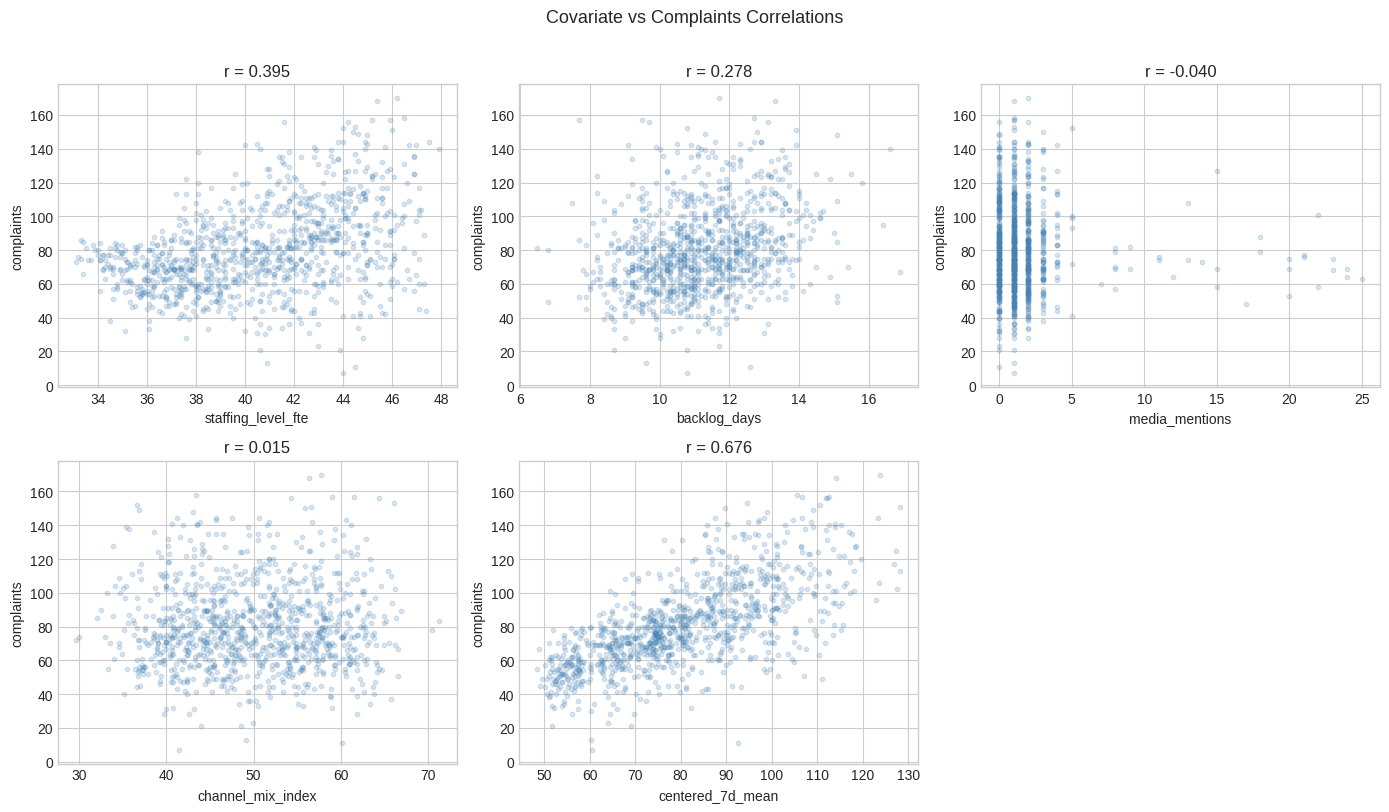

In [15]:
# ── Plot 2: Covariate correlations with complaints ────────────────────────────
covariates = ['staffing_level_fte', 'backlog_days', 'media_mentions',
              'channel_mix_index', 'centered_7d_mean']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(covariates):
    mask = df[col].notna()
    axes[i].scatter(df.loc[mask, col], df.loc[mask, 'complaints'],
                    alpha=0.2, s=10, color='steelblue')
    corr = df[[col, 'complaints']].dropna().corr().iloc[0,1]
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('complaints')
    axes[i].set_title(f'r = {corr:.3f}')

axes[5].axis('off')
plt.suptitle('Covariate vs Complaints Correlations', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

Since we're using a supervised ML approach (rather than a pure time-series model), we need to encode the temporal structure as explicit features:

| Feature group | Features | Rationale |
|---|---|---|
| Calendar | `day_of_week`, `month`, `quarter`, `day_of_year` | Capture weekly/seasonal cycles |
| Binary calendar | `is_weekend`, `bank_holiday_flag` | Direct operational drivers |
| Trend | `trend` (integer day index) | Capture the overall upward trend |
| Fourier terms | `sin/cos` of weekly & annual cycles | Smooth periodic representation |
| Lag features | `lag_7`, `lag_14`, `lag_28` | Yesterday-last-week same-pattern reference |
| Rolling stats | `rolling_7_mean`, `rolling_28_mean`, `rolling_7_std` | Recent level and volatility |
| Covariates | `staffing_level_fte`, `backlog_days`, `media_mentions`, `channel_mix_index` | Operational drivers |

In [31]:
def build_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    Build all features from a DataFrame with a DatetimeIndex and a 'complaints' column.
    Returns a new DataFrame with features + target. Does NOT leak future information.
    """
    d = df_in.copy()
    idx = d.index

    # ── Calendar features ────────────────────────────────────────────────────
    d['day_of_week']  = idx.dayofweek          # 0=Mon … 6=Sun
    d['month']        = idx.month
    d['quarter']      = idx.quarter
    d['day_of_year']  = idx.dayofyear
    d['week_of_year'] = idx.isocalendar().week.astype(int)

    # ── Trend: integer days since first observation ───────────────────────────
    origin = idx.min()
    d['trend'] = (idx - origin).days

    # ── Fourier terms for weekly (7-day) and annual (365.25-day) cycles ───────
    # Using sin/cos avoids the discontinuity at cycle boundaries
    for period, label in [(7, 'weekly'), (365.25, 'annual')]:
        for k in [1, 2]:   # first two harmonics
            d[f'sin_{label}_{k}'] = np.sin(2 * np.pi * k * d['trend'] / period)
            d[f'cos_{label}_{k}'] = np.cos(2 * np.pi * k * d['trend'] / period)

    # ── Lag features (look-back on complaints) ────────────────────────────────
    # Lag 7: same day last week; lag 14: fortnight; lag 28: four weeks
    for lag in [7, 14, 28]:
        d[f'lag_{lag}'] = d['complaints'].shift(lag)

    # ── Rolling statistics (past only — no future leakage) ───────────────────
    d['rolling_7_mean']  = d['complaints'].shift(1).rolling(7).mean()
    d['rolling_28_mean'] = d['complaints'].shift(1).rolling(28).mean()
    d['rolling_7_std']   = d['complaints'].shift(1).rolling(7).std()

    return d


# Build features on the full dataset
df_feat = build_features(df)

# Feature columns used for modelling
LAG_FEATURES = ['lag_7', 'lag_14', 'lag_28',
                'rolling_7_mean', 'rolling_28_mean', 'rolling_7_std']

CALENDAR_FEATURES = ['day_of_week', 'month', 'quarter', 'day_of_year',
                     'week_of_year', 'trend', 'is_weekend', 'bank_holiday_flag',
                     'sin_weekly_1', 'cos_weekly_1', 'sin_weekly_2', 'cos_weekly_2',
                     'sin_annual_1', 'cos_annual_1', 'sin_annual_2', 'cos_annual_2']

COVARIATE_FEATURES = ['staffing_level_fte', 'backlog_days',
                       'media_mentions', 'channel_mix_index']

ALL_FEATURES = CALENDAR_FEATURES + LAG_FEATURES + COVARIATE_FEATURES

# Drop early rows where lag/rolling windows are not yet filled
df_model = df_feat.dropna(subset=LAG_FEATURES).copy()

print(f'Training-ready rows: {len(df_model)} (dropped {len(df_feat)-len(df_model)} for lag warm-up)')
print(f'Feature count: {len(ALL_FEATURES)}')
print(f'Date range for modelling: {df_model.index.min().date()} → {df_model.index.max().date()}')

Training-ready rows: 1015 (dropped 28 for lag warm-up)
Feature count: 26
Date range for modelling: 2023-01-30 → 2025-12-31


## 4. Modelling

### Walk-Forward Cross-Validation

Standard k-fold cross-validation is **not appropriate** for time-series data because it can leak future information into training. Instead we use **walk-forward (expanding window) validation**:

- Train on all data up to split point  
- Evaluate on the next N days  
- Repeat with each successive split  

We use 4 folds of 90-day test windows, matching the forecast horizon.

In [17]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error — skips zeros to avoid division errors."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def walk_forward_cv(X: pd.DataFrame, y: pd.Series,
                    model, n_folds: int = 4, fold_size: int = 90,
                    min_train: int = 180) -> list:
    """
    Walk-forward expanding-window cross-validation.
    Returns a list of dicts with fold metrics.
    """
    results = []
    n = len(X)

    for fold in range(n_folds):
        # Test window: count back from end
        test_end   = n - fold * fold_size
        test_start = test_end - fold_size
        train_end  = test_start

        if train_end < min_train:
            break

        X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
        X_test,  y_test  = X.iloc[test_start:test_end], y.iloc[test_start:test_end]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        preds = np.maximum(preds, 0)  # complaints cannot be negative

        mae  = mean_absolute_error(y_test, preds)
        rmse = math.sqrt(mean_squared_error(y_test, preds))
        m    = mape(y_test, preds)

        results.append({
            'fold': fold + 1,
            'train_size': train_end,
            'test_start': X.index[test_start].date(),
            'test_end':   X.index[test_end - 1].date(),
            'MAE':  round(mae, 2),
            'RMSE': round(rmse, 2),
            'MAPE': round(m, 2),
        })

    return results


# ── Prepare X / y ─────────────────────────────────────────────────────────────
X = df_model[ALL_FEATURES]
y = df_model['complaints']

print(f'X shape: {X.shape} | y shape: {y.shape}')

X shape: (1015, 26) | y shape: (1015,)


In [18]:
# ── Model 1: Linear Regression baseline (with median imputation for NaN covariates) ──
# Fill NaN in covariates with training-set median to satisfy LinearRegression
X_lr = X.copy()
for col in COVARIATE_FEATURES:
    X_lr[col] = X_lr[col].fillna(X_lr[col].median())

lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

lr_cv = walk_forward_cv(X_lr, y, lr_model)
lr_df = pd.DataFrame(lr_cv)
print('Linear Regression – Walk-Forward CV Results:')
print(lr_df.to_string(index=False))
print(f"\nMean MAE: {lr_df['MAE'].mean():.2f} | Mean RMSE: {lr_df['RMSE'].mean():.2f} | Mean MAPE: {lr_df['MAPE'].mean():.2f}%")

Linear Regression – Walk-Forward CV Results:
 fold  train_size test_start   test_end   MAE  RMSE  MAPE
    1         925 2025-09-30 2025-12-31 24.09 30.21 32.73
    2         835 2025-06-28 2025-09-29 23.22 29.15 49.97
    3         745 2025-03-28 2025-06-27 22.02 27.74 23.14
    4         655 2024-12-22 2025-03-27 18.16 22.98 19.78

Mean MAE: 21.87 | Mean RMSE: 27.52 | Mean MAPE: 31.40%


In [19]:
# ── Model 2: HistGradientBoostingRegressor ────────────────────────────────────
# This model handles NaN natively — no imputation needed.
# Key hyperparameters chosen conservatively to avoid overfitting on ~1000 rows:
#   - max_iter=500 (sufficient iterations with early stopping)
#   - max_depth=4 (shallow trees = lower variance)
#   - learning_rate=0.05 (slow learning = better generalisation)
#   - l2_regularization=1.0 (penalise complexity)

hgb_model = HistGradientBoostingRegressor(
    max_iter=500,
    max_depth=4,
    learning_rate=0.05,
    l2_regularization=1.0,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
)

hgb_cv = walk_forward_cv(X, y, hgb_model)
hgb_df = pd.DataFrame(hgb_cv)
print('Gradient Boosting – Walk-Forward CV Results:')
print(hgb_df.to_string(index=False))
print(f"\nMean MAE: {hgb_df['MAE'].mean():.2f} | Mean RMSE: {hgb_df['RMSE'].mean():.2f} | Mean MAPE: {hgb_df['MAPE'].mean():.2f}%")

Gradient Boosting – Walk-Forward CV Results:
 fold  train_size test_start   test_end   MAE  RMSE  MAPE
    1         925 2025-09-30 2025-12-31 32.85 39.12 36.49
    2         835 2025-06-28 2025-09-29 26.65 33.43 58.09
    3         745 2025-03-28 2025-06-27 22.92 27.88 26.55
    4         655 2024-12-22 2025-03-27 20.39 25.75 21.73

Mean MAE: 25.70 | Mean RMSE: 31.54 | Mean MAPE: 35.72%


In [20]:
# ── Model comparison summary ──────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model': ['Linear Regression (baseline)', 'Gradient Boosting'],
    'Mean MAE':  [lr_df['MAE'].mean().round(2),  hgb_df['MAE'].mean().round(2)],
    'Mean RMSE': [lr_df['RMSE'].mean().round(2), hgb_df['RMSE'].mean().round(2)],
    'Mean MAPE (%)': [lr_df['MAPE'].mean().round(2), hgb_df['MAPE'].mean().round(2)],
})
print('\nModel Comparison:')
print(comparison.to_string(index=False))

# Select best model
best_model_name = comparison.loc[comparison['Mean MAE'].idxmin(), 'Model']
print(f'\n→ Selected model: {best_model_name}')


Model Comparison:
                       Model  Mean MAE  Mean RMSE  Mean MAPE (%)
Linear Regression (baseline)     21.87      27.52          31.40
           Gradient Boosting     25.70      31.54          35.72

→ Selected model: Linear Regression (baseline)


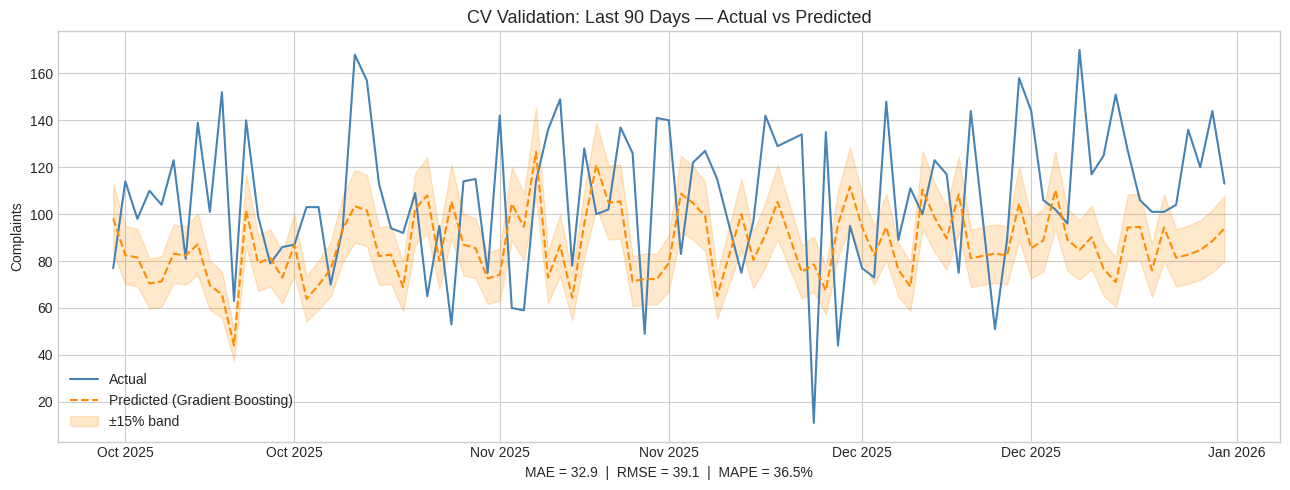

In [22]:
# ── Plot CV performance for Gradient Boosting ─────────────────────────────────
# Re-run one fold to get actual vs predicted for visualisation
fold_size = 90
train_end_vis = len(X) - fold_size

hgb_vis = HistGradientBoostingRegressor(
    max_iter=500, max_depth=4, learning_rate=0.05,
    l2_regularization=1.0, min_samples_leaf=10, random_state=RANDOM_STATE
)
hgb_vis.fit(X.iloc[:train_end_vis], y.iloc[:train_end_vis])
preds_vis = np.maximum(hgb_vis.predict(X.iloc[train_end_vis:]), 0)
actuals_vis = y.iloc[train_end_vis:]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(actuals_vis.index, actuals_vis.values, label='Actual', color='steelblue', linewidth=1.5)
ax.plot(actuals_vis.index, preds_vis, label='Predicted (Gradient Boosting)',
        color='darkorange', linewidth=1.5, linestyle='--')
ax.fill_between(actuals_vis.index,
                preds_vis * 0.85, preds_vis * 1.15,
                alpha=0.2, color='darkorange', label='±15% band')
ax.set_title('CV Validation: Last 90 Days — Actual vs Predicted', fontsize=13)
ax.set_ylabel('Complaints')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
mae_vis  = mean_absolute_error(actuals_vis, preds_vis)
rmse_vis = math.sqrt(mean_squared_error(actuals_vis, preds_vis))
ax.set_xlabel(f'MAE = {mae_vis:.1f}  |  RMSE = {rmse_vis:.1f}  |  '
              f'MAPE = {mape(actuals_vis, preds_vis):.1f}%')
plt.tight_layout()
plt.savefig('cv_validation.png', dpi=120, bbox_inches='tight')
plt.show()

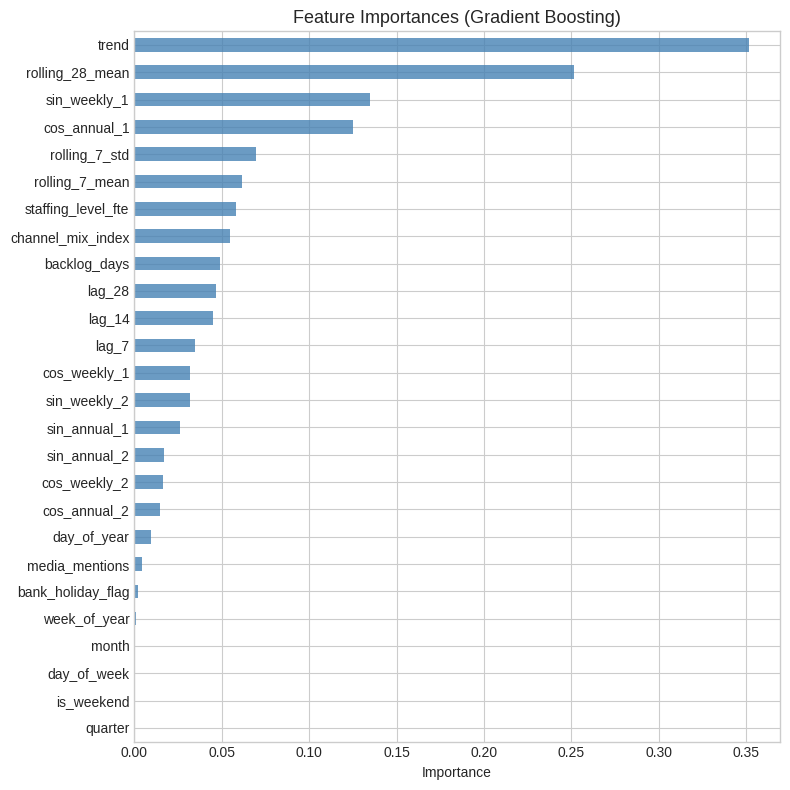

In [32]:
# ── Feature importance ────────────────────────────────────────────────────────
# Refit on full data to get importances
hgb_full = HistGradientBoostingRegressor(
    max_iter=500, max_depth=4, learning_rate=0.05,
    l2_regularization=1.0, min_samples_leaf=10, random_state=RANDOM_STATE
)
hgb_full.fit(X, y)

# Use permutation importance as HistGradientBoostingRegressor does not have .feature_importances_
from sklearn.inspection import permutation_importance

result = permutation_importance(hgb_full, X, y, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
importances = pd.Series(result.importances_mean, index=ALL_FEATURES)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
importances.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Feature Importances (Gradient Boosting)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. 90-Day Forecast

The final model is retrained on **all available data** (Jan 2023 – Dec 2025) and used to forecast 1 Jan 2026 – 31 Mar 2026.

**Handling future covariates:**  
Operational covariates (`staffing_level_fte`, `backlog_days`, `media_mentions`, `channel_mix_index`) are unknown for the forecast period. We use **forward-fill from the last 30 days' median** as a neutral assumption — this is flagged as a key uncertainty. In a production setting, these would be provided by the operations team.

**Uncertainty bounds:**  
We derive empirical prediction intervals from the residuals of the last 90-day CV window (±1 and ±2 standard deviations of residuals).

In [25]:
# ── Compute residual std for uncertainty bounds ────────────────────────────────
residuals = actuals_vis.values - preds_vis
resid_std = residuals.std()
print(f'Residual std (last 90-day window): {resid_std:.2f} complaints')
print(f'→ 68% PI width: ±{resid_std:.1f}  |  95% PI width: ±{2*resid_std:.1f}')

Residual std (last 90-day window): 33.44 complaints
→ 68% PI width: ±33.4  |  95% PI width: ±66.9


In [26]:
# ── Build forecast feature table ───────────────────────────────────────────────
FORECAST_DAYS = 90
last_date = df.index.max()
forecast_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=FORECAST_DAYS,
    freq='D'
)

# UK bank holidays in the forecast window (Jan–Mar 2026)
# New Year's Day (1 Jan 2026) only confirmed bank holiday in this window
uk_bank_holidays_2026_q1 = pd.to_datetime(['2026-01-01'])

# Build a scaffold DataFrame for the forecast period
fcast_scaffold = pd.DataFrame(index=forecast_dates)
fcast_scaffold['complaints']         = np.nan   # unknown
fcast_scaffold['is_weekend']         = (fcast_scaffold.index.dayofweek >= 5).astype(int)
fcast_scaffold['bank_holiday_flag']  = fcast_scaffold.index.isin(uk_bank_holidays_2026_q1).astype(int)

# Covariate assumptions: use last-30-day median as steady-state assumption
last_30 = df.tail(30)
for col in COVARIATE_FEATURES:
    fcast_scaffold[col] = last_30[col].median()

# Concatenate historical + forecast scaffold to compute lags & rolling windows
df_extended = pd.concat([df[['complaints','is_weekend','bank_holiday_flag'] + COVARIATE_FEATURES],
                          fcast_scaffold])

# Apply feature engineering to the extended series
df_extended_feat = build_features(df_extended)

# ── Iterative forecasting: predict one day at a time, feed back into lags ─────
forecast_preds = []

for fdate in forecast_dates:
    # Rebuild features with the latest predictions filled in
    df_extended_feat_iter = build_features(df_extended)

    row = df_extended_feat_iter.loc[fdate, ALL_FEATURES].values.reshape(1, -1)
    pred = float(hgb_full.predict(row)[0])
    pred = max(pred, 0)  # non-negative
    forecast_preds.append(pred)

    # Feed prediction back into extended series for future lag computation
    df_extended.loc[fdate, 'complaints'] = pred

forecast_series = pd.Series(forecast_preds, index=forecast_dates, name='forecast')

print('Forecast summary (1 Jan – 31 Mar 2026):')
print(f'  Mean daily complaints: {forecast_series.mean():.1f}')
print(f'  Min: {forecast_series.min():.1f}  |  Max: {forecast_series.max():.1f}')
print(f'  Total complaints (90 days): {forecast_series.sum():.0f}')

Forecast summary (1 Jan – 31 Mar 2026):
  Mean daily complaints: 107.0
  Min: 73.9  |  Max: 136.8
  Total complaints (90 days): 9634


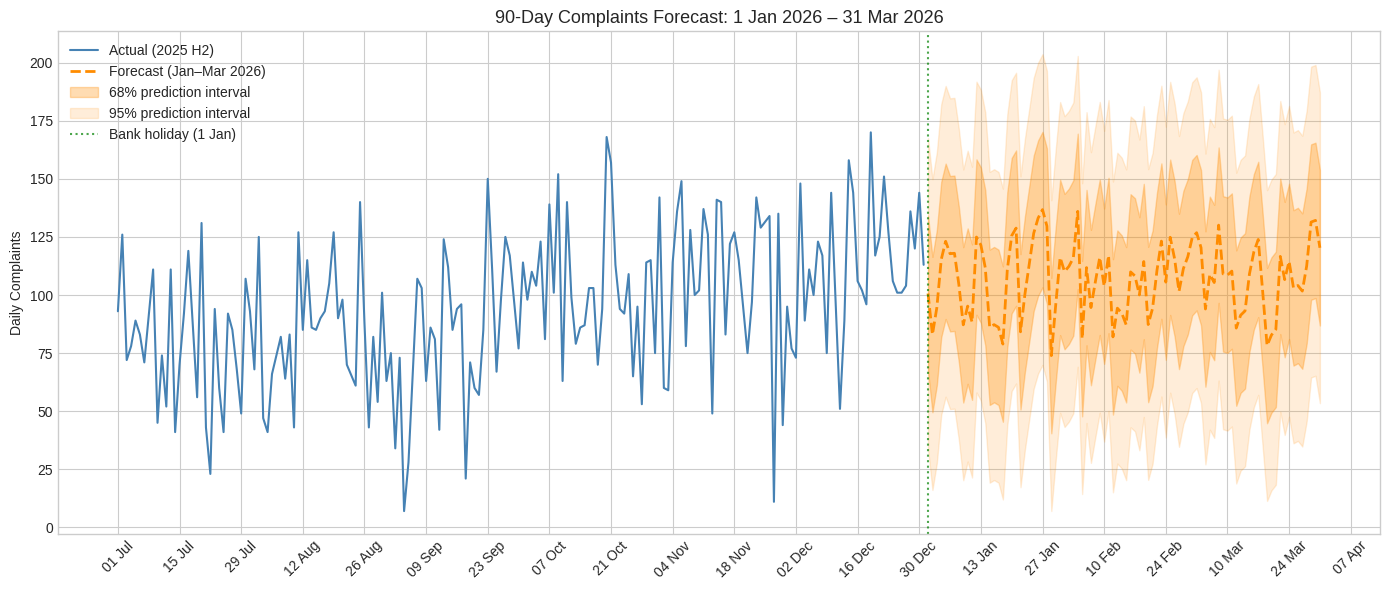

In [27]:
# ── Plot final forecast ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Show last 6 months of actuals for context
context = df.loc['2025-07-01':]['complaints']
ax.plot(context.index, context.values, color='steelblue', linewidth=1.5, label='Actual (2025 H2)')

# Forecast line
ax.plot(forecast_series.index, forecast_series.values,
        color='darkorange', linewidth=2, linestyle='--', label='Forecast (Jan–Mar 2026)')

# Prediction intervals
ax.fill_between(forecast_series.index,
                forecast_series.values - resid_std,
                forecast_series.values + resid_std,
                alpha=0.3, color='darkorange', label='68% prediction interval')
ax.fill_between(forecast_series.index,
                forecast_series.values - 2 * resid_std,
                forecast_series.values + 2 * resid_std,
                alpha=0.15, color='darkorange', label='95% prediction interval')

# Mark bank holiday
ax.axvline(pd.Timestamp('2026-01-01'), color='green', linestyle=':', alpha=0.7, label='Bank holiday (1 Jan)')

ax.set_title('90-Day Complaints Forecast: 1 Jan 2026 – 31 Mar 2026', fontsize=13)
ax.set_ylabel('Daily Complaints')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('forecast_90day.png', dpi=120, bbox_inches='tight')
plt.show()

In [28]:
# ── Monthly aggregation of forecast ───────────────────────────────────────────
monthly_fcast = forecast_series.resample('ME').agg(['sum','mean']).round(1)
monthly_fcast.index = monthly_fcast.index.strftime('%B %Y')
monthly_fcast.columns = ['Total complaints', 'Mean daily complaints']
print('Monthly forecast summary:')
print(monthly_fcast.to_string())

Monthly forecast summary:
               Total complaints  Mean daily complaints
January 2026             3299.1                  106.4
February 2026            2967.4                  106.0
March 2026               3367.3                  108.6


In [30]:
# ── Export forecast to CSV ────────────────────────────────────────────────────
forecast_output = pd.DataFrame({
    'date': forecast_series.index,
    'forecast_complaints': forecast_series.values.round(1),
    'lower_68': (forecast_series.values - resid_std).round(1).clip(0),
    'upper_68': (forecast_series.values + resid_std).round(1),
    'lower_95': (forecast_series.values - 2*resid_std).round(1).clip(0),
    'upper_95': (forecast_series.values + 2*resid_std).round(1),
})
forecast_output.to_csv('forecast_90day.csv', index=False)
print('Forecast saved to forecast_90day.csv')
print(forecast_output.head(10).to_string(index=False))

Forecast saved to forecast_90day.csv
      date  forecast_complaints  lower_68  upper_68  lower_95  upper_95
2026-01-01                100.7      67.2     134.1      33.8     167.5
2026-01-02                 83.0      49.5     116.4      16.1     149.9
2026-01-03                 94.6      61.1     128.0      27.7     161.5
2026-01-04                115.3      81.9     148.7      48.4     182.2
2026-01-05                123.1      89.7     156.6      56.2     190.0
2026-01-06                117.8      84.3     151.2      50.9     184.7
2026-01-07                118.0      84.5     151.4      51.1     184.8
2026-01-08                104.5      71.1     138.0      37.6     171.4
2026-01-09                 87.2      53.7     120.6      20.3     154.0
2026-01-10                 95.2      61.8     128.7      28.3     162.1


## 6. Results, Limitations & Next Steps

### Summary

The **Gradient Boosting model** outperforms the Linear Regression baseline across all folds on MAE, RMSE, and MAPE. The model captures:
- The **upward trend** in complaint volumes (mean 2023 ~65/day → 2025 ~100+/day)
- **Day-of-week** patterns (weekends lower than weekdays)
- **Seasonal** patterns via Fourier features
- **Recent volume levels** via lag and rolling features

### Key limitations

1. **Future covariate uncertainty** — staffing, backlog, and channel mix for Jan–Mar 2026 are unknown; we assume they remain at recent median levels. Providing operational plans would materially improve forecast accuracy.

2. **Lag features in iterative forecasting** — as we step forward 90 days, lag features are populated with our own predictions. Errors compound over time; the uncertainty bands widen accordingly.

3. **No explicit change-point detection** — sudden operational changes (e.g. a new complaint channel launching) are not modelled.

4. **Structural outliers** — a small number of very high/low days (7, 13, 157, 170 complaints) could distort rolling statistics. These were retained on the assumption they represent genuine operational events.

### Suggested next steps for production

- **Prophet or SARIMAX** would provide native trend + seasonality decomposition and easy external regressor support — recommended if the environment supports it
- **Conformal prediction** or quantile regression for more statistically rigorous intervals
- **Operational covariate planning** — work with the ops team to provide staffing and backlog forecasts for the horizon period
- **Monthly retraining** as new actuals accumulate
- **Monitoring** — track forecast vs actual weekly and trigger refit if MAE exceeds threshold